In [5]:
# !pip install pyclustering

KMeans (k=3) Labels: [1 1 1 1 1 1 1 1 1 1]


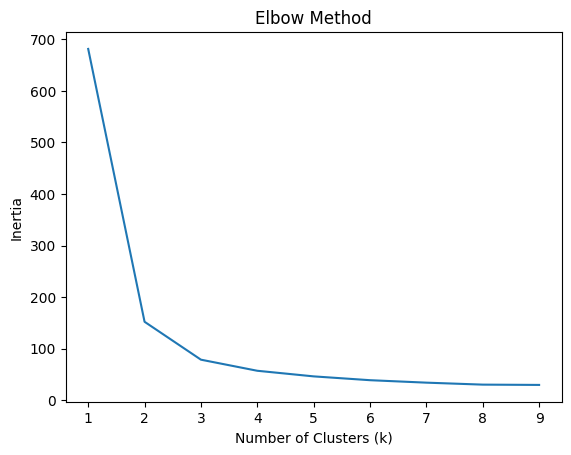

Pyclustering Clusters (first 2): [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], [52, 77, 100, 102, 103, 104, 105, 107, 108, 109, 110, 111, 112, 115, 116, 117, 118, 120, 122, 124, 125, 128, 129, 130, 131, 132, 134, 135, 136, 137, 139, 140, 141, 143, 144, 145, 147, 148]]
Pyclustering Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- Analysis ---
KMeans (sklearn) clusters: 3


NameError: name 'labels_opt' is not defined

In [6]:
# EXERCISE 1: K-MEANS CLUSTERING (SKLEARN + ELBOW + PYCLUSTERING)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pyclustering.cluster.kmeans import kmeans
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer

# -------------------------------
# 1. Load dataset
# -------------------------------
df = pd.read_csv("iris.csv")

# Drop categorical column
X = df.drop("Species", axis=1)

# -------------------------------
# 2. Apply KMeans (k=3)
# -------------------------------
kmeans_model = KMeans(n_clusters=3, random_state=42)
labels_k3 = kmeans_model.fit_predict(X)

print("KMeans (k=3) Labels:", labels_k3[:10])

# 3. Elbow Method

inertia = []
k_range = range(1, 10)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Plot Elbow Graph
plt.plot(k_range, inertia)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# 4. pyclustering KMeans

X_list = X.values.tolist()

initial_centers = kmeans_plusplus_initializer(X_list, 3).initialize()
py_kmeans = kmeans(X_list, initial_centers)

py_kmeans.process()
clusters = py_kmeans.get_clusters()

print("Pyclustering Clusters (first 2):", clusters[:2])

# 5. Assign labels (pyclustering)

labels_py = [0] * len(X_list)
for i, cluster in enumerate(clusters):
    for index in cluster:
        labels_py[index] = i

print("Pyclustering Labels:", labels_py[:10])

# 6. Comparison Analysis

print("\n--- Analysis ---")
print("KMeans (sklearn) clusters:", len(set(labels_k3)))
print("KMeans (optimal k) clusters:", len(set(labels_opt)))
print("Pyclustering clusters:", len(clusters))

print("\nObservation:")
print("Elbow method helps find optimal k (usually 3 for Iris).")
print("Sklearn KMeans uses centroids (mean).")
print("Pyclustering KMeans gives similar clusters but uses different implementation.")

In [ ]:
# !pip install kneed

from kneed import KneeLocator

k1 = KneeLocator(range(1,10), inertia)

In [ ]:
# EXERCISE 2: K-MEDOIDS + COMPARISON WITH K-MEANS

import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import random
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.cluster import KMeans

# 1. Load dataset

df = pd.read_csv("iris.csv")

# Drop categorical column
X = df.drop("Species", axis=1).values.tolist()

# -------------------------------
# 2. Select random initial medoids
# -------------------------------
initial_medoids = random.sample(range(len(X)), 3)

# 3. Apply K-Medoids

kmedoids_instance = kmedoids(X, initial_medoids)
kmedoids_instance.process()

# -------------------------------
# 4. Get clusters and medoids
# -------------------------------
clusters = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

print("K-Medoids Clusters (first 2):", clusters[:2])
print("Final Medoids:", medoids)

# -------------------------------
# 5. Assign cluster labels
# -------------------------------
labels_kmedoids = [0] * len(X)
for i, cluster in enumerate(clusters):
    for index in cluster:
        labels_kmedoids[index] = i

print("K-Medoids Labels (first 10):", labels_kmedoids[:10])

# -------------------------------
# 6. K-Means for comparison
# -------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(df.drop("Species", axis=1))

print("K-Means Labels (first 10):", labels_kmeans[:10])

# -------------------------------
# 7. Basic Analysis
# -------------------------------
print("\n--- Analysis ---")
print("Number of clusters (K-Medoids):", len(clusters))
print("Number of clusters (K-Means):", len(set(labels_kmeans)))

print("\nObservation:")
print("K-Medoids uses actual data points as centers (medoids).")
print("K-Means uses mean values (centroids).")
print("K-Medoids is more robust to outliers than K-Means.")

K-Medoids Clusters (first 2): [[50, 51, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 106, 113, 114, 119, 121, 123, 126, 127, 133, 138, 142, 146, 149], [52, 77, 100, 102, 103, 104, 105, 107, 108, 109, 110, 111, 112, 115, 116, 117, 118, 120, 122, 124, 125, 128, 129, 130, 131, 132, 134, 135, 136, 137, 139, 140, 141, 143, 144, 145, 147, 148]]
Final Medoids: [78, 112, 7]
K-Medoids Labels (first 10): [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
K-Means Labels (first 10): [1 1 1 1 1 1 1 1 1 1]

--- Analysis ---
Number of clusters (K-Medoids): 3
Number of clusters (K-Means): 3

Observation:
K-Medoids uses actual data points as centers (medoids).
K-Means uses mean values (centroids).
K-Medoids is more robust to outliers than K-Means.
